# Combined BNS + NSBH — Universal Angle with Fixed $f_j^{\mathrm{BNS}}$ Scan

This notebook runs three independent MCMCs with fixed BNS jet-launching fraction:

- $f_j^{\mathrm{BNS}} = 0.3$
- $f_j^{\mathrm{BNS}} = 0.5$
- $f_j^{\mathrm{BNS}} = 1.0$

while keeping $f_j^{\mathrm{NSBH}}$ fixed to the catalogue-driven value in the codebase.

The final section compares the joint posterior distributions of $(\theta_c^{\mathrm{BNS}}, \theta_c^{\mathrm{NSBH}})$ across these three runs.

In [21]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import emcee

import sys
sys.path.insert(0, '..')

plt.style.use('../configurations/style.mplstyle')
datafiles = Path('../datafiles')

print('Setup complete.')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup complete.


In [22]:
from src.nsbh.init import initialize_combined_simulation
from src.top_hat.montecarlo import (
    create_k_interpolator,
    compute_luminosity_distance,
    simplified_montecarlo,
    apply_detection_cuts,
    score_func_cvm,
    poiss_log,
    run_mcmc,
    check_and_resume_mcmc,
)
from src.top_hat.geometric_eff import geometric_efficiency_fixed
from src.nsbh.montecarlo import GBM_EFF, FJ_NSBH_FIXED, N_MC_EVENTS
import src.init

demo_params = {
    'alpha'         : -0.6,
    'beta_s'        : -2.5,
    'n'             : 2.0,
    'theta_c'       : 3.4,
    'theta_v_max'   : 10.0,
    'z_model'       : 'fiducial_delayed_A0.5',
}

bns_params, nsbh_data, data_dict = initialize_combined_simulation(
    datafiles=datafiles,
    params=demo_params,
    size_test=2_000,
    nsbh_population='fiducial_delayed_cut',
    nsbh_alpha='A0.5',
)

k_interpolator = create_k_interpolator()
bns_distances = compute_luminosity_distance(bns_params.z_arr)
nsbh_distances = nsbh_data.distances

print(f'BNS events/yr:  {len(bns_params.z_arr)}')
print(f'NSBH events/yr: {len(nsbh_data.z_arr)}')
print(f'Observed yearly GRB rate: {bns_params.yearly_rate:.2f}')
print(f'fj_nsbh fixed at: {FJ_NSBH_FIXED}')

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332
BNS events/yr:  60187
NSBH events/yr: 18332
Observed yearly GRB rate: 18.58
fj_nsbh fixed at: 1


## Likelihood with Fixed $f_j^{\mathrm{BNS}}$

The MCMC parameter vector is now 6-dimensional:

$$
[A_{\mathrm{index}}, \log_{10}L_0, \log_{10}\mu_E, \sigma_E, \theta_c^{\mathrm{BNS}}, \theta_c^{\mathrm{NSBH}}]
$$

In [23]:
def log_likelihood_combined_universal_fixed_fj_bns(
    thetas,
    fj_bns_fixed,
    bns_params,
    nsbh_data,
    bns_distances,
    nsbh_distances,
    k_interpolator,
    n_events=N_MC_EVENTS,
):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, theta_c_nsbh = thetas
    grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]

    geom_eff_bns = geometric_efficiency_fixed(theta_c_bns)
    geom_eff_nsbh = geometric_efficiency_fixed(theta_c_nsbh)

    epsilon_bns = geom_eff_bns * fj_bns_fixed
    epsilon_nsbh = geom_eff_nsbh * FJ_NSBH_FIXED

    intrinsic_bns = epsilon_bns * len(bns_params.z_arr) * GBM_EFF
    intrinsic_nsbh = epsilon_nsbh * len(nsbh_data.z_arr) * GBM_EFF

    bns_results = simplified_montecarlo(
        grb_thetas, n_events, bns_params, bns_distances, k_interpolator
    )
    bns_trig, bns_analysis = apply_detection_cuts(
        bns_results['p_flux'], bns_results['E_p_obs']
    )

    nsbh_results = simplified_montecarlo(
        grb_thetas, n_events, nsbh_data, nsbh_distances, k_interpolator, rng=bns_params.rng
    )
    nsbh_trig, nsbh_analysis = apply_detection_cuts(
        nsbh_results['p_flux'], nsbh_results['E_p_obs']
    )

    pflux_det = np.concatenate([
        bns_results['p_flux'][bns_analysis],
        nsbh_results['p_flux'][nsbh_analysis],
    ])
    epeak_det = np.concatenate([
        bns_results['E_p_obs'][bns_analysis],
        nsbh_results['E_p_obs'][nsbh_analysis],
    ])

    if len(pflux_det) <= 3:
        return -np.inf, -np.inf, -np.inf, -np.inf

    logL_pflux = score_func_cvm(pflux_det, bns_params.pflux_data, bns_params.rng)
    logL_epeak = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)

    phys_eff_bns = np.sum(bns_trig) / n_events
    phys_eff_nsbh = np.sum(nsbh_trig) / n_events

    predicted_bns = intrinsic_bns * bns_params.triggered_years * phys_eff_bns
    predicted_nsbh = intrinsic_nsbh * bns_params.triggered_years * phys_eff_nsbh
    predicted_total = predicted_bns + predicted_nsbh

    observed_total = bns_params.yearly_rate * bns_params.triggered_years
    if predicted_total <= 0:
        return -np.inf, -np.inf, -np.inf, -np.inf

    logL_poisson = poiss_log(k=observed_total, mu=predicted_total)
    return logL_pflux + logL_epeak + logL_poisson, logL_pflux, logL_epeak, logL_poisson


def log_prior_fixed_fj_bns(thetas):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, theta_c_nsbh = thetas

    if not (1.5 < A_index < 12):
        return -np.inf
    if not (-2 < L_L0 < 7):
        return -np.inf
    if not (0.1 < L_mu_E < 7):
        return -np.inf
    if not (0 < sigma_E < 2.5):
        return -np.inf
    if not (1 < theta_c_bns < 40):
        return -np.inf
    if not (1 < theta_c_nsbh < 50):
        return -np.inf

    return 0.0


def initialize_walkers_fixed_fj_bns(n_walkers, seed=42):
    rng = np.random.default_rng(seed)
    return np.column_stack([
        rng.uniform(2, 3, n_walkers),
        rng.uniform(2, 4, n_walkers),
        rng.uniform(2, 4, n_walkers),
        rng.uniform(0.2, 1.0, n_walkers),
        rng.uniform(5, 10, n_walkers),
        rng.uniform(5, 10, n_walkers),
    ])

## Run Three MCMCs ($10^4$ Steps Each)

In [24]:
N_STEPS_ALL     = 100_000
N_PARAMS        = 6
N_WALKERS       = 20
N_STEPS         = N_STEPS_ALL
FJ_BNS_LIST     = [0.3, 0.5, 1.0]

run_dirs = {}
for fj_bns_fixed in FJ_BNS_LIST:
    tag = str(fj_bns_fixed).replace('.', 'p')
    run_name = f'NSBH_universal_fixed_fjBNS_{tag}'
    out_dir = src.init.create_run_dir(run_name, output_files_default='Output_files')
    run_dirs[fj_bns_fixed] = out_dir

    def log_probability(thetas, fj=fj_bns_fixed):
        lp = log_prior_fixed_fj_bns(thetas)
        if not np.isfinite(lp):
            return -np.inf, 0.0, 0.0, 0.0

        ll = log_likelihood_combined_universal_fixed_fj_bns(
            thetas=thetas,
            fj_bns_fixed=fj,
            bns_params=bns_params,
            nsbh_data=nsbh_data,
            bns_distances=bns_distances,
            nsbh_distances=nsbh_distances,
            k_interpolator=k_interpolator,
            n_events=N_MC_EVENTS,
        )
        if not np.isfinite(ll[0]):
            return -np.inf, 0.0, 0.0, 0.0

        return lp + ll[0], ll[1], ll[2], ll[3]

    backend_path = out_dir / 'emcee.h5'
    initial_pos, n_steps_remaining, backend = check_and_resume_mcmc(
        filename=backend_path,
        n_steps=N_STEPS,
        initialize_walkers_func=initialize_walkers_fixed_fj_bns,
        n_walkers=N_WALKERS,
    )

    print(f'Running fj_bns={fj_bns_fixed} | output={out_dir}')
    sampler = run_mcmc(
        log_probability_func=log_probability,
        initial_walkers=initial_pos,
        n_iterations=n_steps_remaining,
        n_walkers=N_WALKERS,
        n_params=N_PARAMS,
        backend=backend,
        blobs_dtype=[('l_pflux', float), ('l_epeak', float), ('l_poiss', float)],
    )

    print(f'Completed fj_bns={fj_bns_fixed}: {backend.iteration} total steps saved.')

print('All runs complete.')

Loading existing directory  : Output_files/NSBH_universal_fixed_fjBNS_0p3
Continuing from iteration 80000
Running fj_bns=0.3 | output=Output_files/NSBH_universal_fixed_fjBNS_0p3


100%|██████████| 20000/20000 [27:07<00:00, 12.29it/s]


Completed fj_bns=0.3: 100000 total steps saved.
Loading existing directory  : Output_files/NSBH_universal_fixed_fjBNS_0p5
Continuing from iteration 80000
Running fj_bns=0.5 | output=Output_files/NSBH_universal_fixed_fjBNS_0p5


100%|██████████| 20000/20000 [27:44<00:00, 12.02it/s]


Completed fj_bns=0.5: 100000 total steps saved.
Loading existing directory  : Output_files/NSBH_universal_fixed_fjBNS_1p0
Continuing from iteration 80000
Running fj_bns=1.0 | output=Output_files/NSBH_universal_fixed_fjBNS_1p0


100%|██████████| 20000/20000 [29:59<00:00, 11.12it/s]

Completed fj_bns=1.0: 100000 total steps saved.
All runs complete.


## Load Chains and Compare Joint $\theta_c$ Posterior

Overlay 2D density contours in the $(\theta_c^{\mathrm{BNS}}, \theta_c^{\mathrm{NSBH}})$ plane for each fixed $f_j^{\mathrm{BNS}}$.

In [25]:
from scipy.stats import gaussian_kde

burn_frac       = 0.33
thin            = 10
samples_by_fj   = {}

for fj_bns_fixed, out_dir in run_dirs.items():
    backend = emcee.backends.HDFBackend(out_dir / 'emcee.h5')
    burn = int(backend.iteration * burn_frac)
    flat = backend.get_chain(discard=burn, thin=thin, flat=True)
    samples_by_fj[fj_bns_fixed] = flat
    print(f'fj_bns={fj_bns_fixed}: samples={len(flat)} after burn/thin')

fj_bns=0.3: samples=134000 after burn/thin
fj_bns=0.5: samples=134000 after burn/thin
fj_bns=1.0: samples=134000 after burn/thin


## BNS-Only Baseline (`f_j^{NSBH}=0`) and Before/After Comparison

This section removes NSBH contributions entirely:

- no NSBH rate term
- no NSBH Monte Carlo
- no sampling of $\theta_c^{\mathrm{NSBH}}$

We run the same fixed `f_j^{BNS}` list and compare the posterior of $\theta_c^{\mathrm{BNS}}$ with the combined (BNS+NSBH) case.

In [26]:
# BNS-only likelihood: fj_nsbh = 0 and no theta_c_nsbh parameter

def log_likelihood_bns_only_fixed_fj_bns(
    thetas,
    fj_bns_fixed,
    bns_params,
    bns_distances,
    k_interpolator,
    n_events=N_MC_EVENTS,
):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns = thetas
    grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]

    geom_eff_bns = geometric_efficiency_fixed(theta_c_bns)
    epsilon_bns = geom_eff_bns * fj_bns_fixed
    intrinsic_bns = epsilon_bns * len(bns_params.z_arr) * GBM_EFF

    bns_results = simplified_montecarlo(
        grb_thetas, n_events, bns_params, bns_distances, k_interpolator
    )
    bns_trig, bns_analysis = apply_detection_cuts(
        bns_results['p_flux'], bns_results['E_p_obs']
    )

    pflux_det = bns_results['p_flux'][bns_analysis]
    epeak_det = bns_results['E_p_obs'][bns_analysis]

    if len(pflux_det) <= 3:
        return -np.inf, -np.inf, -np.inf, -np.inf

    logL_pflux = score_func_cvm(pflux_det, bns_params.pflux_data, bns_params.rng)
    logL_epeak = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)

    phys_eff_bns = np.sum(bns_trig) / n_events
    predicted_total = intrinsic_bns * bns_params.triggered_years * phys_eff_bns

    observed_total = bns_params.yearly_rate * bns_params.triggered_years
    if predicted_total <= 0:
        return -np.inf, -np.inf, -np.inf, -np.inf

    logL_poisson = poiss_log(k=observed_total, mu=predicted_total)
    return logL_pflux + logL_epeak + logL_poisson, logL_pflux, logL_epeak, logL_poisson


def log_prior_bns_only_fixed_fj_bns(thetas):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns = thetas

    if not (1.5 < A_index < 12):
        return -np.inf
    if not (-2 < L_L0 < 7):
        return -np.inf
    if not (0.1 < L_mu_E < 7):
        return -np.inf
    if not (0 < sigma_E < 2.5):
        return -np.inf
    if not (1 < theta_c_bns < 40):
        return -np.inf

    return 0.0


def initialize_walkers_bns_only(n_walkers, seed=84):
    rng = np.random.default_rng(seed)
    return np.column_stack([
        rng.uniform(2, 3, n_walkers),
        rng.uniform(2, 4, n_walkers),
        rng.uniform(2, 4, n_walkers),
        rng.uniform(0.2, 1.0, n_walkers),
        rng.uniform(5, 10, n_walkers),
    ])

N_PARAMS_BNS_ONLY = 5
N_STEPS_BNS_ONLY = N_STEPS_ALL

run_dirs_bns_only = {}
for fj_bns_fixed in FJ_BNS_LIST:
    tag = str(fj_bns_fixed).replace('.', 'p')
    run_name = f'NSBH_universal_BNS_only_fjBNS_{tag}'
    out_dir = src.init.create_run_dir(run_name, output_files_default='Output_files')
    run_dirs_bns_only[fj_bns_fixed] = out_dir

    def log_probability_bns_only(thetas, fj=fj_bns_fixed):
        lp = log_prior_bns_only_fixed_fj_bns(thetas)
        if not np.isfinite(lp):
            return -np.inf, 0.0, 0.0, 0.0

        ll = log_likelihood_bns_only_fixed_fj_bns(
            thetas=thetas,
            fj_bns_fixed=fj,
            bns_params=bns_params,
            bns_distances=bns_distances,
            k_interpolator=k_interpolator,
            n_events=N_MC_EVENTS,
        )
        if not np.isfinite(ll[0]):
            return -np.inf, 0.0, 0.0, 0.0

        return lp + ll[0], ll[1], ll[2], ll[3]

    backend_path = out_dir / 'emcee.h5'
    initial_pos, n_steps_remaining, backend = check_and_resume_mcmc(
        filename=backend_path,
        n_steps=N_STEPS_BNS_ONLY,
        initialize_walkers_func=initialize_walkers_bns_only,
        n_walkers=N_WALKERS,
    )

    print(f'Running BNS-only fj_bns={fj_bns_fixed} | output={out_dir}')
    sampler = run_mcmc(
        log_probability_func=log_probability_bns_only,
        initial_walkers=initial_pos,
        n_iterations=n_steps_remaining,
        n_walkers=N_WALKERS,
        n_params=N_PARAMS_BNS_ONLY,
        backend=backend,
        blobs_dtype=[('l_pflux', float), ('l_epeak', float ), ('l_poiss', float)],
    )

    print(f'Completed BNS-only fj_bns={fj_bns_fixed}: {backend.iteration} total steps saved.')

print('All BNS-only runs complete.')

Loading existing directory  : Output_files/NSBH_universal_BNS_only_fjBNS_0p3
Continuing from iteration 80000
Running BNS-only fj_bns=0.3 | output=Output_files/NSBH_universal_BNS_only_fjBNS_0p3


100%|██████████| 20000/20000 [25:39<00:00, 13.00it/s]


Completed BNS-only fj_bns=0.3: 100000 total steps saved.
Loading existing directory  : Output_files/NSBH_universal_BNS_only_fjBNS_0p5
Continuing from iteration 80000
Running BNS-only fj_bns=0.5 | output=Output_files/NSBH_universal_BNS_only_fjBNS_0p5


100%|██████████| 20000/20000 [21:43<00:00, 15.34it/s]


Completed BNS-only fj_bns=0.5: 100000 total steps saved.
Loading existing directory  : Output_files/NSBH_universal_BNS_only_fjBNS_1p0
Continuing from iteration 80000
Running BNS-only fj_bns=1.0 | output=Output_files/NSBH_universal_BNS_only_fjBNS_1p0


100%|██████████| 20000/20000 [22:11<00:00, 15.02it/s]

Completed BNS-only fj_bns=1.0: 100000 total steps saved.
All BNS-only runs complete.


BNS-only fj_bns=0.3: samples=134000 after burn/thin
BNS-only fj_bns=0.5: samples=134000 after burn/thin
BNS-only fj_bns=1.0: samples=134000 after burn/thin


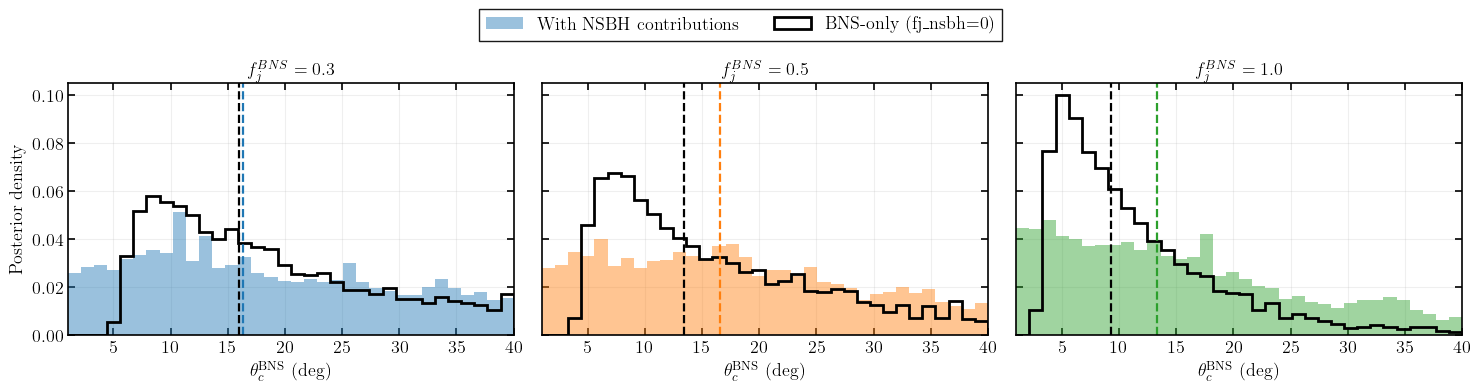

In [27]:
# Load BNS-only chains and compare theta_c_bns before/after NSBH contributions

burn_frac_bns_only = 0.33
thin_bns_only = 10
samples_bns_only_by_fj = {}

for fj_bns_fixed, out_dir in run_dirs_bns_only.items():
    backend = emcee.backends.HDFBackend(out_dir / 'emcee.h5')
    burn = int(backend.iteration * burn_frac_bns_only)
    flat = backend.get_chain(discard=burn, thin=thin_bns_only, flat=True)
    samples_bns_only_by_fj[fj_bns_fixed] = flat
    print(f'BNS-only fj_bns={fj_bns_fixed}: samples={len(flat)} after burn/thin')


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

colors = {
    0.3: 'C0',
    0.5: 'C1',
    1.0: 'C2',
}

for ax, fj_bns_fixed in zip(axes, FJ_BNS_LIST):
    theta_with_nsbh = samples_by_fj[fj_bns_fixed][:, 4]
    theta_bns_only = samples_bns_only_by_fj[fj_bns_fixed][:, 4]

    bins = np.linspace(1, 40, 35)
    ax.hist(
        theta_with_nsbh,
        bins=bins,
        density=True,
        alpha=0.45,
        color=colors[fj_bns_fixed],
        label='With NSBH contributions',
    )
    ax.hist(
        theta_bns_only,
        bins=bins,
        density=True,
        histtype='step',
        linewidth=2.0,
        color='black',
        label='BNS-only (fj_nsbh=0)',
    )

    med_with = np.median(theta_with_nsbh)
    med_bonly = np.median(theta_bns_only)
    ax.axvline(med_with, color=colors[fj_bns_fixed], ls='--', lw=1.6)
    ax.axvline(med_bonly, color='black', ls='--', lw=1.6)

    ax.set_title(rf'$f_j^{{BNS}}={fj_bns_fixed}$')
    ax.set_xlim(1, 40)
    ax.set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ (deg)')
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Posterior density')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

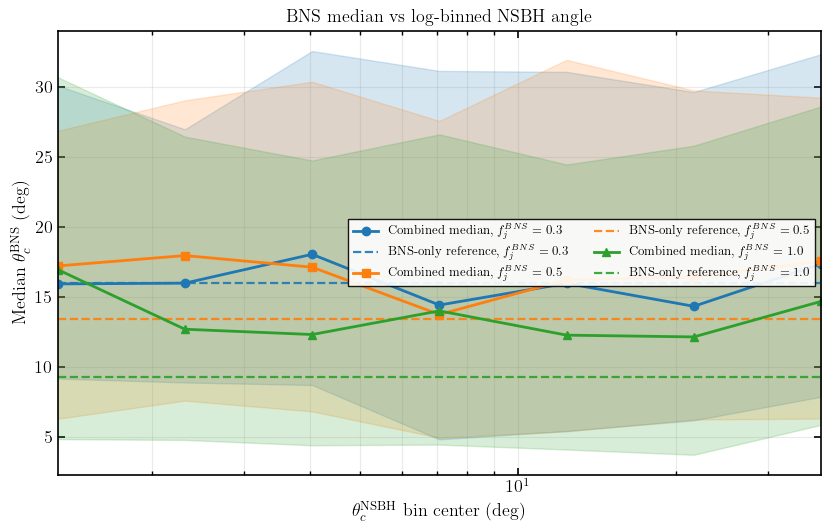

In [28]:
# Median theta_c_bns versus log-binned theta_c_nsbh, with BNS-only reference medians

nsbh_bins = np.logspace(np.log10(1.0), np.log10(50.0), 8)
nsbh_bin_centers = np.sqrt(nsbh_bins[:-1] * nsbh_bins[1:])

fig, ax = plt.subplots(figsize=(8.5, 5.5))
markers = {0.3: 'o', 0.5: 's', 1.0: '^'}

for fj_bns_fixed in FJ_BNS_LIST:
    flat = samples_by_fj[fj_bns_fixed]
    theta_bns = flat[:, 4]
    theta_nsbh = flat[:, 5]
    ref_median = np.median(samples_bns_only_by_fj[fj_bns_fixed][:, 4])

    binned_medians = []
    binned_lows = []
    binned_highs = []

    for left, right in zip(nsbh_bins[:-1], nsbh_bins[1:]):
        mask = (theta_nsbh >= left) & (theta_nsbh < right)
        subset = theta_bns[mask]
        if len(subset) == 0:
            binned_medians.append(np.nan)
            binned_lows.append(np.nan)
            binned_highs.append(np.nan)
        else:
            binned_medians.append(np.median(subset))
            binned_lows.append(np.percentile(subset, 16))
            binned_highs.append(np.percentile(subset, 84))

    ax.plot(
        nsbh_bin_centers,
        binned_medians,
        marker=markers[fj_bns_fixed],
        color=colors[fj_bns_fixed],
        lw=2,
        label=rf'Combined median, $f_j^{{BNS}}={fj_bns_fixed}$',
    )
    ax.fill_between(
        nsbh_bin_centers,
        binned_lows,
        binned_highs,
        color=colors[fj_bns_fixed],
        alpha=0.18,
    )
    ax.axhline(
        ref_median,
        color=colors[fj_bns_fixed],
        ls='--',
        lw=1.6,
        alpha=0.9,
        label=rf'BNS-only reference, $f_j^{{BNS}}={fj_bns_fixed}$',
    )

ax.set_xscale('log')
ax.set_xlim(1.0, 50.0)
ax.set_xlabel(r'$\theta_c^{\mathrm{NSBH}}$ bin center (deg)')
ax.set_ylabel(r'Median $\theta_c^{\mathrm{BNS}}$ (deg)')
ax.set_title(r'BNS median vs log-binned NSBH angle')
ax.grid(True, which='both', alpha=0.25)
ax.legend(fontsize=9, ncol=2)
bin_center = np.sqrt(nsbh_bins[:-1] * nsbh_bins[1:])
plt.xlim(min(bin_center), max(bin_center))
plt.tight_layout()
plt.show()

fj_bns=0.3: corr(1-cos(theta_nsbh), 1-cos(theta_bns)) = 0.064
fj_bns=0.5: corr(1-cos(theta_nsbh), 1-cos(theta_bns)) = 0.005
fj_bns=1.0: corr(1-cos(theta_nsbh), 1-cos(theta_bns)) = 0.074


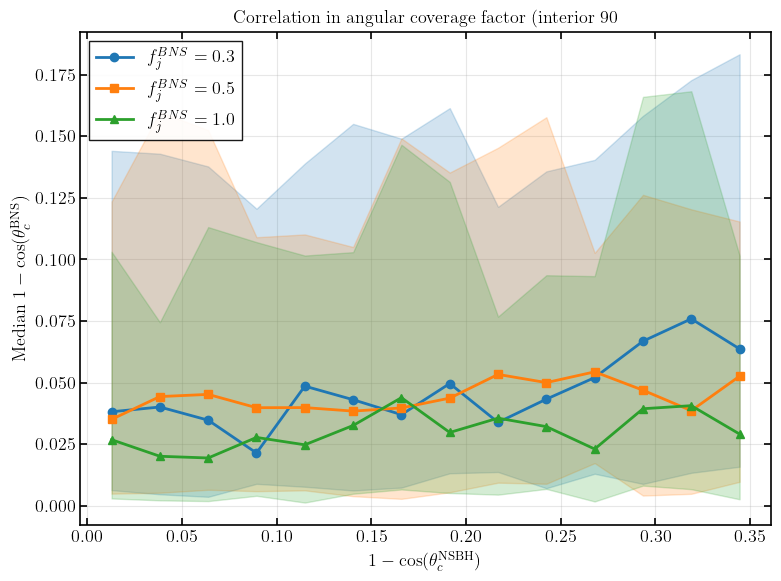

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Bins in 1 - cos(theta) space for NSBH
# NSBH prior is 1 to 50 deg
min_nsbh_cos = 1 - np.cos(np.radians(1))
max_nsbh_cos = 1 - np.cos(np.radians(50))
cos_bins = np.linspace(min_nsbh_cos, max_nsbh_cos, 15)
cos_bin_centers = 0.5 * (cos_bins[:-1] + cos_bins[1:])

fig, ax = plt.subplots(figsize=(8, 6))

for fj_bns_fixed in FJ_BNS_LIST:
    flat = samples_by_fj[fj_bns_fixed]
    theta_bns = flat[:, 4]
    theta_nsbh = flat[:, 5]
    
    # Calculate 1 - cos(theta) metrics
    nsbh_cos_factor = 1 - np.cos(np.radians(theta_nsbh))
    bns_cos_factor = 1 - np.cos(np.radians(theta_bns))
    
    # Print overall correlation
    cos_corr = np.corrcoef(nsbh_cos_factor, bns_cos_factor)[0, 1]
    print(f"fj_bns={fj_bns_fixed}: corr(1-cos(theta_nsbh), 1-cos(theta_bns)) = {cos_corr:.3f}")
    
    binned_medians = []
    binned_lows = []
    binned_highs = []
    valid_centers = []
    
    for left, right in zip(cos_bins[:-1], cos_bins[1:]):
        mask = (nsbh_cos_factor >= left) & (nsbh_cos_factor < right)
        bns_subset = theta_bns[mask]
        bns_cos_subset = bns_cos_factor[mask]
        
        if len(bns_subset) > 50: # Ensure enough samples in the bin
            # Check if 90% of the original posterior in this bin is comfortably within the [1, 40] prior bounds
            p05, p95 = np.percentile(bns_subset, [5, 95])
            
            # Using 1.1 and 39.9 to check if the 90% interval is clear of the exact boundary
            if p05 > 1.1 and p95 < 39.9:
                valid_centers.append(0.5 * (left + right))
                binned_medians.append(np.median(bns_cos_subset))
                binned_lows.append(np.percentile(bns_cos_subset, 16))
                binned_highs.append(np.percentile(bns_cos_subset, 84))
                
    if valid_centers:
        ax.plot(
            valid_centers,
            binned_medians,
            marker=markers[fj_bns_fixed] if 'markers' in globals() else 'o',
            color=colors[fj_bns_fixed],
            lw=2,
            label=rf'$f_j^{{BNS}}={fj_bns_fixed}$',
        )
        ax.fill_between(
            valid_centers,
            binned_lows,
            binned_highs,
            color=colors[fj_bns_fixed],
            alpha=0.2,
        )

ax.set_xlabel(r'$1 - \cos(\theta_c^{\mathrm{NSBH}})$')
ax.set_ylabel(r'Median $1 - \cos(\theta_c^{\mathrm{BNS}})$')
ax.set_title(r'Correlation in angular coverage factor (interior 90% bounds)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()